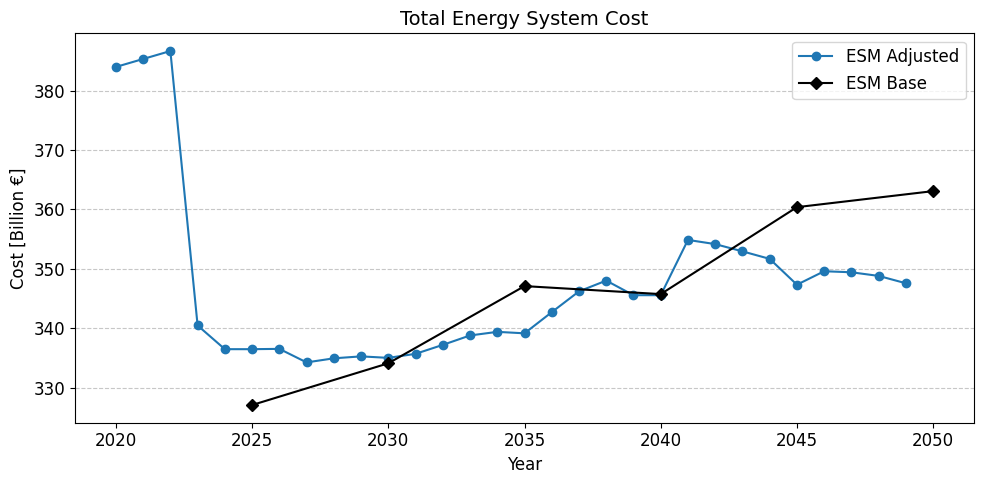

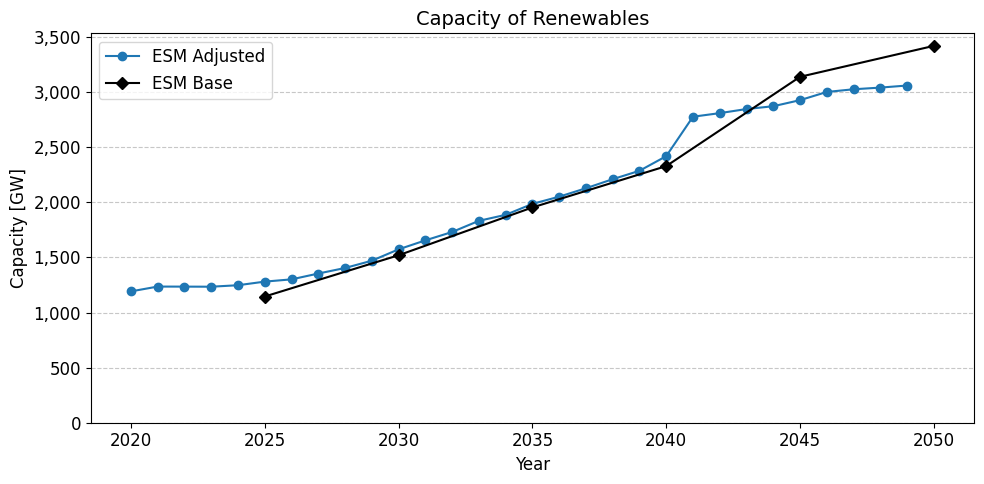

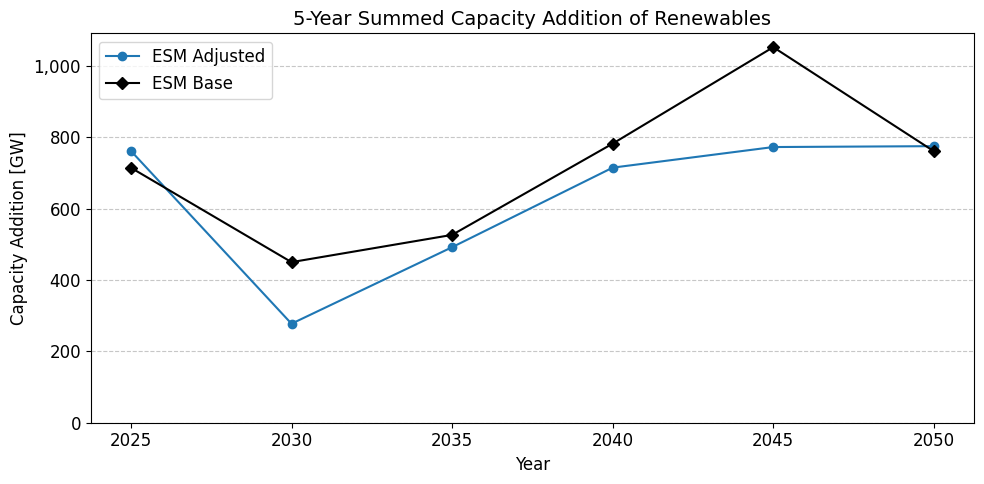

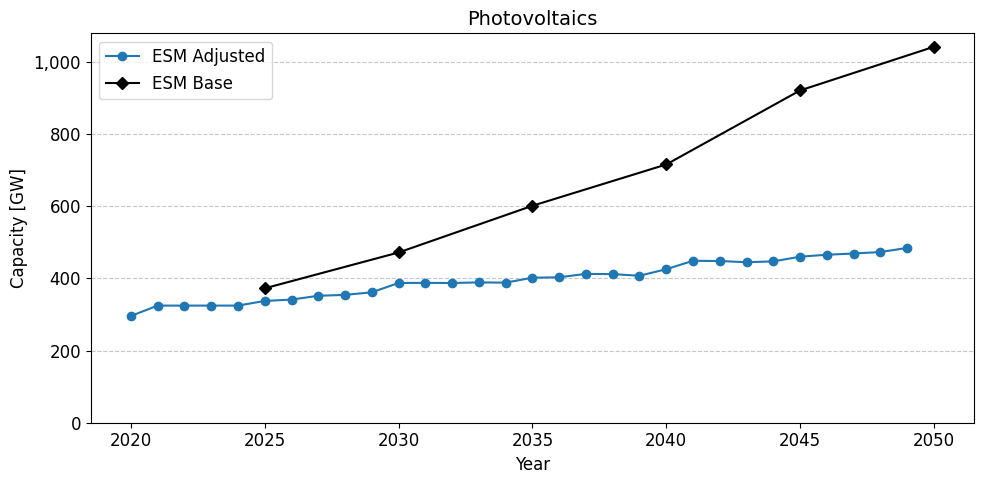

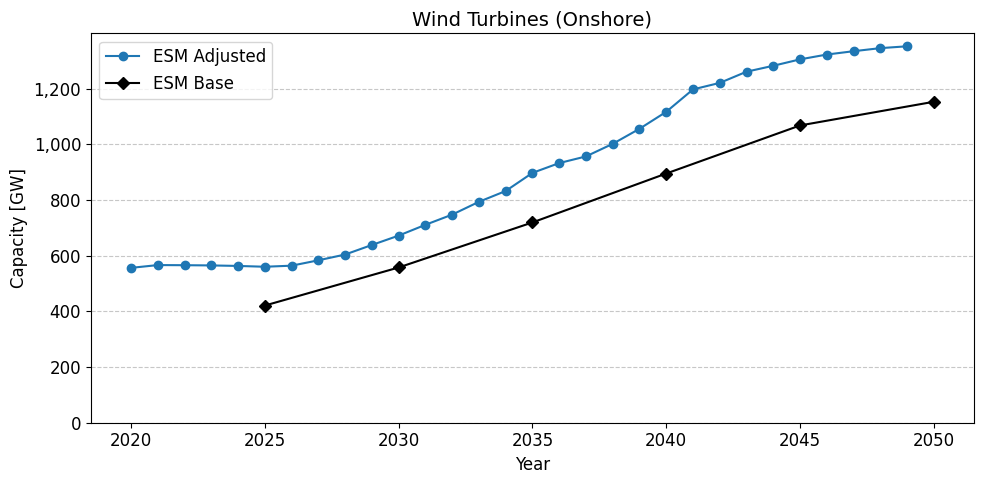

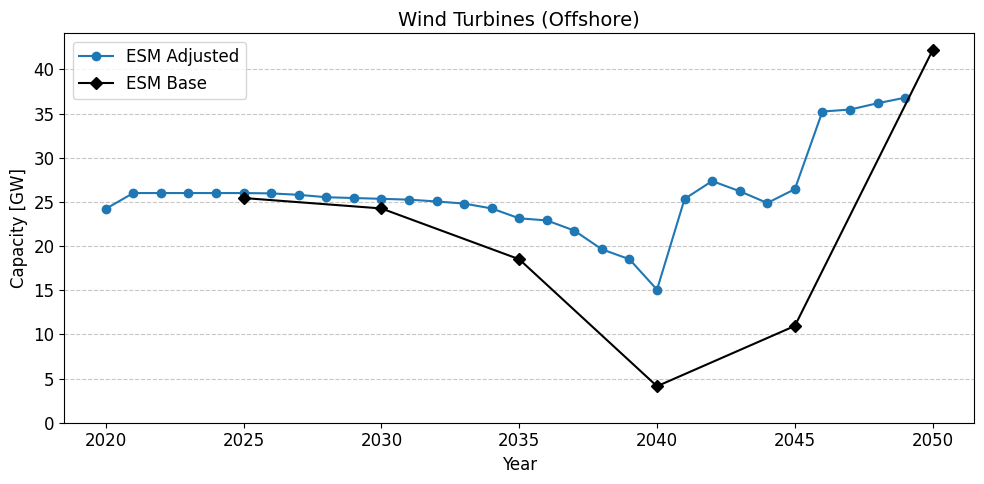

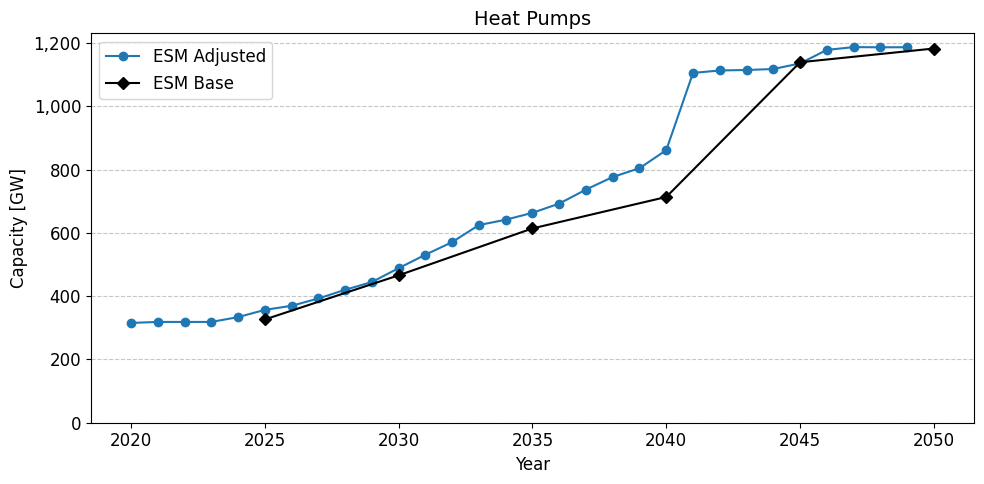

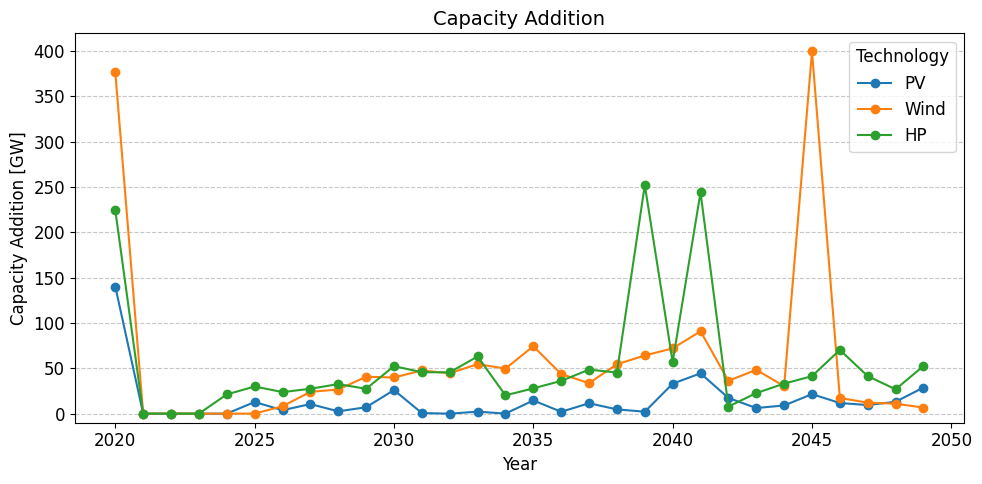

In [7]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.ticker as mtick
from zen_garden.postprocess.results import Results

# === Dataset Setup ===
input_datasets = [
    '2020_70ts_30a',
    'energy_transition_example_output',
]

input_labels = ['ESM_adjusted', 'ESM_base']

paths_input = [os.path.join("outputs", name) for name in input_datasets]
results_input = [Results(path) for path in paths_input]

input_start_years = {
    'ESM_adjusted': 2020,
    'ESM_base': 2025,
}

input_intervals = {
    'ESM_adjusted': 1,
    'ESM_base': 5,
}

label_names = {
    'ESM_adjusted': 'ESM Adjusted',
    'ESM_base': 'ESM Base'
}

conversion_techs = ['photovoltaics', 'wind_onshore', 'wind_offshore', 'heat_pump']

# === Define save path
save_path = r"C:\Users\nicol\OneDrive\Desktop\Semester_project\Plots_and_Figures\ESM_plots\output"
os.makedirs(save_path, exist_ok=True)

# === Styling
plt.rcParams.update({'font.size': 12})

marker_styles = {
    'ESM_adjusted': 'o',
    'ESM_base': 'D',
}

colors = {
    'ESM_adjusted': '#1f77b4',
    'ESM_base': 'black'
}

# === Cost Comparison Plot ===
try:
    plt.figure(figsize=(10, 5))
    for res, label in zip(results_input, input_labels):
        cost = res.get_total('cost_total')  # in MEUR
        start_year = input_start_years[label]
        step = input_intervals.get(label, 1)
        cost.index = list(range(start_year, start_year + len(cost) * step, step))
        cost_in_beuro = cost * 1e6 / 1e9  # MEUR → EUR → Billion €

        plt.plot(cost_in_beuro.index, cost_in_beuro.values,
                 marker=marker_styles[label],
                 linestyle='-',
                 linewidth=1.5,
                 color=colors[label],
                 label=label_names[label])

    plt.title('Total Energy System Cost', fontsize=14)
    plt.xlabel('Year')
    plt.ylabel('Cost [Billion €]')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.savefig(os.path.join(save_path, "energy_system_cost_comparison.pdf"), format='pdf', bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f"Error plotting cost_total: {e}")


# === Reusable Plot Function
def plot_series(title, y_label, component, tech_filter=None, binning=False, ylim_bottom=0, split_techs_by_dataset=False, legend_loc='upper left'):
    try:
        plt.figure(figsize=(10, 5))

        if split_techs_by_dataset:
            # Only for 'ESM_adjusted' dataset
            res = results_input[input_labels.index('ESM_adjusted')]
            label = 'ESM_adjusted'
            df = res.get_total(component)
            start_year = input_start_years[label]
            step = input_intervals.get(label, 1)
            df.columns = list(range(start_year, start_year + df.shape[1] * step, step))

            # Custom legend labels
            custom_labels = {
                'photovoltaics': 'PV',
                'wind_onshore': 'Wind',
                'heat_pump': 'HP'
            }

            if tech_filter and 'technology' in df.index.names:
                for tech in tech_filter:
                    df_tech = df.loc[df.index.get_level_values('technology') == tech]
                    total = df_tech.sum(axis=0)

                    if binning and label == 'ESM_adjusted':
                        bin_edges = [2020, 2025, 2030, 2035, 2040, 2045, 2050]
                        bin_labels = [2025, 2030, 2035, 2040, 2045, 2050]
                        binned = pd.cut(total.index, bins=bin_edges, labels=bin_labels, right=False)
                        total = total.groupby(binned, observed=False).sum()
                        total.index = total.index.astype(int)

                    plt.plot(total.index, total.values,
                             marker='o',
                             linestyle='-',
                             linewidth=1.5,
                             label=custom_labels.get(tech, tech))

            plt.ylim(bottom=-10)

        else:
            for res, label in zip(results_input, input_labels):
                df = res.get_total(component)
                start_year = input_start_years[label]
                step = input_intervals.get(label, 1)
                df.columns = list(range(start_year, start_year + df.shape[1] * step, step))

                if tech_filter and 'technology' in df.index.names:
                    df = df.loc[df.index.get_level_values('technology').isin(tech_filter)]

                total = df.sum(axis=0)

                if binning and label == 'ESM_adjusted':  # Only bin adjusted dataset
                    bin_edges = [2020, 2025, 2030, 2035, 2040, 2045, 2050]
                    bin_labels = [2025, 2030, 2035, 2040, 2045, 2050]
                    binned = pd.cut(total.index, bins=bin_edges, labels=bin_labels, right=False)
                    total = total.groupby(binned, observed=False).sum()
                    total.index = total.index.astype(int)

                plt.plot(total.index, total.values,
                         marker=marker_styles[label],
                         linestyle='-',
                         linewidth=1.5,
                         color=colors[label],
                         label=label_names[label])

            plt.ylim(bottom=ylim_bottom)

        plt.title(title, fontsize=14)
        plt.xlabel('Year')
        plt.ylabel(y_label)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))
        plt.legend(title='Technology' if split_techs_by_dataset else None, loc=legend_loc)
        plt.tight_layout()
        filename = title.replace("–", "-").replace(" ", "_").replace("(", "").replace(")", "").lower()
        plt.savefig(os.path.join(save_path, f"{filename}.pdf"), format='pdf', bbox_inches='tight')
        plt.show()

    except Exception as e:
        print(f"Error plotting {title.lower()}: {e}")


# === Plot Calls
plot_series(
    title='Capacity of Renewables',
    y_label='Capacity [GW]',
    component="capacity",
    tech_filter=conversion_techs,
    ylim_bottom=0
)

plot_series(
    title='5-Year Summed Capacity Addition of Renewables',
    y_label='Capacity Addition [GW]',
    component="capacity_addition",
    tech_filter=conversion_techs,
    binning=True,
    ylim_bottom=0
)

# === Individual Technology Capacity Plots
plot_series(
    title='Photovoltaics',
    y_label='Capacity [GW]',
    component="capacity",
    tech_filter=['photovoltaics'],
    ylim_bottom=0
)

plot_series(
    title='Wind Turbines (Onshore)',
    y_label='Capacity [GW]',
    component="capacity",
    tech_filter=['wind_onshore'],
    ylim_bottom=0
)

plot_series(
    title='Wind Turbines (Offshore)',
    y_label='Capacity [GW]',
    component="capacity",
    tech_filter=['wind_offshore'],
    ylim_bottom=0
)

plot_series(
    title='Heat Pumps',
    y_label='Capacity [GW]',
    component="capacity",
    tech_filter=['heat_pump'],
    ylim_bottom=0
)

plot_series(
    title='Capacity Addition',
    y_label='Capacity Addition [GW]',
    component="capacity_addition",
    tech_filter=['photovoltaics', 'wind_onshore', 'heat_pump'],
    split_techs_by_dataset=True,
    legend_loc='upper right',
    ylim_bottom=-20
)
